# CAPSTONE PROJECT ECOSORT

## PERTANYAAN BISNIS
- Pertanyaan 1 : Bagaimana membangun model klasifikasi sampah berbasis gambar dengan akurasi minimal 85% dalam waktu 2 bulan menggunakan dataset yang telah dikumpulkan?
- Pertanyaan 2 : Jenis sampah apa yang memiliki jumlah data paling sedikit dan bagaimana distribusinya, sehingga dapat dilakukan penyeimbangan data sebelum proses training dalam waktu 1 minggu?


##Library yang dipakai

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import random
import hashlib
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.utils import save_img
import numpy as np
import shutil
from sklearn.model_selection import train_test_split
from concurrent.futures import ThreadPoolExecutor

- Kode diatas berfungsi untuk memanggil seluruh library yang akan digunakan pada project capstone Waste Classification ini.
- Setelah seluruh library yang dibutuhkan sudah dipanggil, selanjutnya akan masuk ke tahap Data Wrangling, dimulai dari Gathering Data.

## DATA WRANGLING

### GATHERING DATA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


- Kode diatas berguna untuk menghubungkan Google Colab dengan Google Drive.
- Setelah berhasil terhubung dengan Google Drive, selanjutkan akan dilakukan pendefinisian untuk dataset yang akan kita gunakan.

In [ ]:
base_path = "/content/drive/MyDrive/Dataset_Waste_Classification_FIX"

- Kode diatas akan melakukan pendefinisian terhadap folder dataset yang akan digunakan.
- Setelah berhasil melakukan pendefinisian, selanjutnya akan diperiksa apakah data sudah di load atau belum.

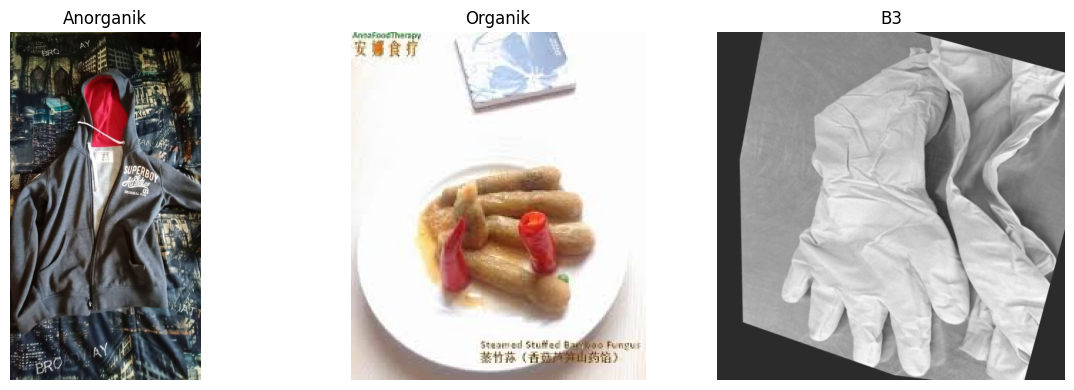

In [ ]:
plt.figure(figsize=(12,4))

folders = os.listdir(base_path)

for i, folder in enumerate(folders):

    folder_path = os.path.join(base_path, folder)

    if os.path.isdir(folder_path):

        files = os.listdir(folder_path)

        # skip kalau folder kosong
        if len(files) == 0:
            continue

        img_file = random.choice(files)

        img_path = os.path.join(folder_path, img_file)

        try:
            img = Image.open(img_path)

            plt.subplot(1, 3, i+1)
            plt.imshow(img)
            plt.title(folder)
            plt.axis('off')

        except Exception as e:
            print(f"Gagal membuka gambar: {img_path}")
            print(e)

plt.tight_layout()
plt.show()

- Kode diatas akan menghasilkan output berupa contoh salah satu dari tiap kategori sampah yang akan digunakan.
- Kode tersebut dapat dijalankan dengan baik. Pada output terlihat bahwa salah satu contoh dari masing-masing kategori sampah berhasil dipanggil, dan sesuai dengan yang diharapkan.
- Tahapan pada Gathering Data sudah selesai dan selanjutnya akan masuk ke tahap Assessing Data.

### ASSESSING DATA

In [ ]:
for folder in os.listdir(base_path):
    print(folder, len(os.listdir(os.path.join(base_path, folder))))

Anorganik 19090
Organik 16885
B3 16356


- Kode diatas akan menghasilkan output berupa jumlah dataset dari tipe-tipe kategori.
- Kode tersebut dapat dijalankan dengan baik. Pada output telah ditampilkan jumlah data dari masing-masing kategori sampah.
- Selanjutnya, akan diperiksa imbalance ratio dari keseluruhan dataset tersebut.

In [ ]:
base_path = '/content/drive/MyDrive/Dataset_Waste_Classification_FIX'
data = {f: len(os.listdir(os.path.join(base_path, f))) for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))}

total = sum(data.values())
min_val = min(data.values())

print(f"{'Kategori':<12} | {'Jumlah':<8} | {'Persentase':<10} | {'Ratio':<5}")
print("-" * 45)
for cat, count in data.items():
    perc = (count / total) * 100
    ratio = count / min_val
    print(f"{cat:<12} | {count:<8} | {perc:>9.2f}% | {ratio:>4.2f}")

print(f"\nTotal Data: {total}")
print(f"Status: {'Imbalance' if max(data.values())/min_val > 1.5 else 'Balance'}")

Kategori     | Jumlah   | Persentase | Ratio
---------------------------------------------
Anorganik    | 19090    |     36.48% | 1.17
Organik      | 16885    |     32.27% | 1.03
B3           | 16356    |     31.25% | 1.00

Total Data: 52331
Status: Balance


- Kode diatas akan menghasilkan output berupa jumlah, persentase, dan ratio dari masing-masing kategori sampah.
- Kode tersebut dapat dijalankan dengan baik. Pada output telah ditampilkan output berupa kategori, jumlah, persentase, total data, serta status dari dataset tersebut.
- Selanjutnya, akan diperiksa apakah terdapat file corrupt pada dataset.

In [ ]:
for root, dirs, files in os.walk(base_path):
    for file in files:
        try:
            img = Image.open(os.path.join(root, file))
            img.verify()
        except:
            print("Corrupt: ", file)

- Kode diatas akan menghasilkan output berupa jumlah file yang corrupt dari keseluruhan dataset.
- Kode tersebut dapat dijalankan dengan baik. Pada output tidak ditampilkan jumlah file yang corrupt.
- Selanjutnya akan diperiksa format file dari keseluruhan data.

In [ ]:
formats = set()

for root, dirs, files in os.walk(base_path):
    for file in files:
        ext = file.split('.')[-1].lower()
        formats.add(ext)

print("Format ditemukan:", formats)

Format ditemukan: {'jpg', 'jpeg'}


- Kode diatas akan menghasilkan output berupa jenis-jenis format file dari kesulurahan dataset.
- Kode tersebut dapat dijalankan dengan baik. Pada output telah ditampilkan jenis-jenis format file pada keseluruhan data.
- Selanjutnya akan diperiksa ukuran dari tiap file pada keseluruhan dataset.

In [ ]:
sizes = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        try:
            img = Image.open(os.path.join(root, file))
            sizes.append(img.size)  # (width, height)
        except:
            pass

# lihat beberapa ukuran unik
print("Contoh ukuran: ", list(set(sizes))[:10])
print("Total variasi ukuran: ", len(set(sizes)))

Contoh ukuran:  [(306, 304), (479, 412), (433, 116), (277, 277), (1200, 1600), (276, 318), (400, 613), (315, 160), (2968, 2984), (234, 172)]
Total variasi ukuran:  2896


- Kode diatas akan menghasilkan output berupa jumlah ukuran dan total variasi ukuran pada keseluruhan dataset.
- Kode tersebut dapat dijalankan dengan baik. Pada output telah ditampilkan contoh ukuran dan total variasi ukuran pada keseluruhan dataset.
- Selanjutnya akan diperiksa jumlah duplikasi dari keseluruhan dataset.

In [ ]:
hashes = {}
duplicates = []

for root, dirs, files in os.walk(base_path):
    for file in files:

        path = os.path.join(root, file)

        try:
            with open(path, 'rb') as f:
                filehash = hashlib.md5(f.read()).hexdigest()

            # jika hash sudah ada
            if filehash in hashes:

                original = hashes[filehash]

                duplicates.append((original, path))

            else:
                hashes[filehash] = path

        except Exception as e:
            print("Error:", path)

print("Jumlah duplikat: ", len(duplicates))

Jumlah duplikat:  928


- Kode diatas akan menghasilkan output berupa jumlah duplikat pada keseluruhan dataset.
- Kode tersebut dapat dijalankan dengan baik. Pada output telah ditampilkan jumlah duplikat pada keseluruhan dataset.

Insight
- Seluruh proses pada assessing data telah selesai, dan memperoleh beberapa informasi terkait dataset.
- Telah dilakukan pemanggilan dataset, dan diperoleh jumlah data Anorganik sebanyak 19090 gambar, Organik sebanyak 16885, dan B3 sebanyak 16356.
- Telah dilakukan pemeriksaan imbalance ratio, dan diperoleh informasi bahwa dataset memiliki keseimbangan yang baik karena memiliki nilai ratio yang baik.
- Telah dilakukan pemeriksaan corrupt file, dan diperoleh informasi bahwa tidak ada file yang corrupt.
- Telah dilakukan pemeriksaan format file, dan diperoleh informasi bahwa terdapat dua jenis format file yaitu jpg dan jpeg. Akan dilakukan penanganan berupa perubahan format file sehingga hanya menjadi satu jenis format file pada tahap cleaning data.
- Telah dilakukan pemeriksaan jenis ukuran dan total variasi ukuran, dan diperoleh informasi bahwa terdapat 2896 variasi ukuran. Akan dilakukan penanganan berupa perubahan variasi ukuran sehingga hanya menjadi satu jenis variasi ukuran pada tahap cleaning data.
- Telah dilakukan pemeriksaan jumlah duplikasi, dan diperoleh informasi bahwa terdapat 928 file duplikasi. Akan dilakukan penanganan berupa perubahan penghapusan file duplikasi sehingga tidak ada file duplikasi pada tahap cleaning data.
- Seluruh proses pada assessing data sudah selesai. Selanjutnya akan masuk ke tahap cleaning data.

### CLEANING DATA

Berikut merupakan hal yang harus diperbaiki
- Merubah jenis format file dari yang sebelumnya jpg dan jpeg, menjadi jpg saja.
- Merubah variasi ukuran pada dataset dari yang sebelumnya 2896 variasi ukuran, menjadi 1 variasi ukuran
- Menghapus duplikasi file dari yang sebelumnya 928 file duplikasi, menjadi 0 file duplikasi.
- Pertama, akan diubah seluruh format file menjadi jpg.

In [ ]:
from PIL import Image
import os

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".jpeg"):
            path = os.path.join(root, file)

            img = Image.open(path).convert("RGB")
            new_path = os.path.splitext(path)[0] + ".jpg"
            img.save(new_path, "JPEG")

            os.remove(path)

- Kode diatas berfungsi untuk mengubah seluruh format file dari yang sebelumnya terdapat jpeg, dan jpg, menjadi hanya jpg saja.
- Kode tersebut dapat dijalankan dengan baik. Artinya seluruh format file berhasil diubah ke format jpg.
- Selanjutnya akan diperiksa jenis format filenya.

In [ ]:
formats = set()

for root, dirs, files in os.walk(base_path):
    for file in files:
        ext = file.split('.')[-1].lower()
        formats.add(ext)

print("Format ditemukan:", formats)

Format ditemukan: {'jpg'}


- Kode diatas akan menghasilkan output berupa jenis format yang ada pada keseluruhan dataset.
- Kode tersebut dapat dijalankan dengan baik. Pada output telah ditampilkan format ditemukan pada keseluruhan dataset.
- Selanjutnya akan dilakukan perubahan variasi ukuran menjadi satu jenis variasi ukuran.

In [ ]:
target_size = (224, 224)

for root, dirs, files in os.walk(base_path):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            img = img.convert("RGB")

            resized_img = img.resize(target_size)

            resized_img.save(path)

        except Exception as e:
            print("Error:", path, e)

print("Resize selesai")

Resize selesai


- Kode diatas akan menghasilkan output berupa "Resize Selesai" yang menunjukkan bahwa proses resize sudah selesai sesua dengan ukuran yang diminta.
- Selanjutnya akan diperiksa ukuran dari beberapa contoh gambar tiap kategori dengan visualisasi.


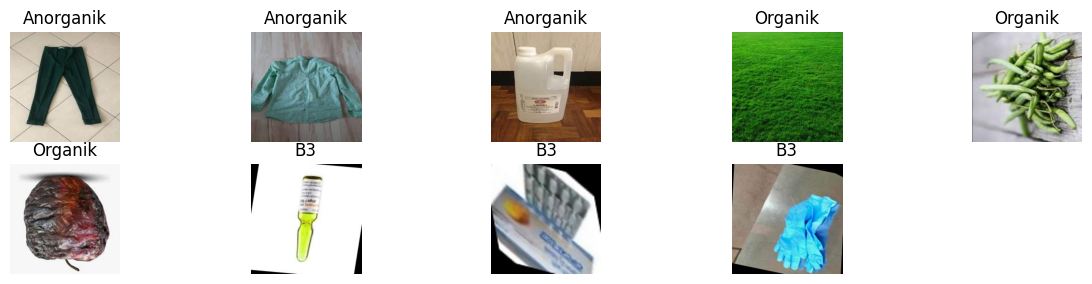

In [ ]:
plt.figure(figsize=(15,10))

i = 1
for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)

    if os.path.isdir(folder_path):
        images = os.listdir(folder_path)

        for img_file in random.sample(images, min(3, len(images))):
            img_path = os.path.join(folder_path, img_file)
            img = Image.open(img_path)

            plt.subplot(6, 5, i)
            plt.imshow(img)
            plt.title(folder)
            plt.axis('off')
            i += 1

plt.show()

- Kode diatas akan menghasilkan output berupa contoh gambar dari masing-masing kategori.
- Kode tersebut dapat dijalankan dengan baik. Pada output telah ditampilkan contoh gambar dari berbagai kategori, dan menunjukkan bahwa semuanya sudah memiliki ukuran yang sama.
- Selanjutnya akan dilakukan penghapusan file duplikasi.

In [ ]:
deleted = 0

for original, dup in duplicates:

    try:
        os.remove(dup)

        deleted += 1

        print("Dihapus:", dup)

    except Exception as e:
        print("Gagal hapus:", dup, e)

print("Total file duplikat terhapus:", deleted)

Dihapus: /content/drive/MyDrive/Dataset_Waste_Classification_FIX/Anorganik/plastic_266.jpg
Dihapus: /content/drive/MyDrive/Dataset_Waste_Classification_FIX/Anorganik/plastic_312.jpg
Dihapus: /content/drive/MyDrive/Dataset_Waste_Classification_FIX/Anorganik/plastic_347.jpg
Dihapus: /content/drive/MyDrive/Dataset_Waste_Classification_FIX/Anorganik/plastic_395.jpg
Dihapus: /content/drive/MyDrive/Dataset_Waste_Classification_FIX/Anorganik/plastic_373.jpg
Dihapus: /content/drive/MyDrive/Dataset_Waste_Classification_FIX/Anorganik/plastic_380.jpg
Dihapus: /content/drive/MyDrive/Dataset_Waste_Classification_FIX/Anorganik/plastic_420.jpg
Dihapus: /content/drive/MyDrive/Dataset_Waste_Classification_FIX/Anorganik/plastic_400.jpg
Dihapus: /content/drive/MyDrive/Dataset_Waste_Classification_FIX/Anorganik/plastic_421.jpg
Dihapus: /content/drive/MyDrive/Dataset_Waste_Classification_FIX/Anorganik/plastic_454.jpg
Dihapus: /content/drive/MyDrive/Dataset_Waste_Classification_FIX/Anorganik/plastic_473.jpg

- Kode diatas akan menghasilkan output semua file yang dihapus karena merupakan file duplikasi.
- Kode ini berjalan dengan baik. Pada output telah ditampilkan semua file yang dihapus karena merupakan file duplikasi.
- Selanjutnya akan diperiksa apakah semua file duplikasi sudah berhasil dihapus.

In [ ]:
#Cek ulang Duplikasi
hashes = {}
duplicates = []

for root, dirs, files in os.walk(base_path):
    for file in files:

        path = os.path.join(root, file)

        try:
            with open(path, 'rb') as f:
                filehash = hashlib.md5(f.read()).hexdigest()

            # jika hash sudah ada
            if filehash in hashes:

                original = hashes[filehash]

                duplicates.append((original, path))

            else:
                hashes[filehash] = path

        except Exception as e:
            print("Error:", path)

print("Jumlah duplikat:", len(duplicates))

Jumlah duplikat: 0


- Kode diatas akan menghasilkan output berupa jumlah file duplikat yang masih ada pada keseluruhan dataset.
- Kode ini berjalan dengan baik. Pada output telah ditampilkan jumlah file duplikat yang sudah tidak ada pada keseluruhan dataset.







Insight
- Seluruh tahapan pada proses cleaning data sudah selesai, dan diperoleh beberapa perubahan sebagai berikut.
- Format file pada dataset berhasil diubah. jenis format file dari yang sebelumnya jpg dan jpeg, menjadi jpg saja.
- Variasi ukuran pada dataset dari yang sebelumnya 2896 variasi ukuran, menjadi 1 variasi ukuran
- Penghapusan duplikasi file pda dataset dari yang sebelumnya 928 file duplikasi, menjadi 0 file duplikasi.
- Seluruh tahapan pada proses cleaning data sekaligus data wrangling telah selesai. Selanjutnya akan masuk ke tahap EDA & Visualisasi Data.

##EDA dan Visualisasi Data

#### Pertanyaan 1 : Bagaimana membangun model klasifikasi sampah berbasis gambar dengan akurasi minimal 85% dalam waktu 2 bulan menggunakan dataset yang telah dikumpulkan?



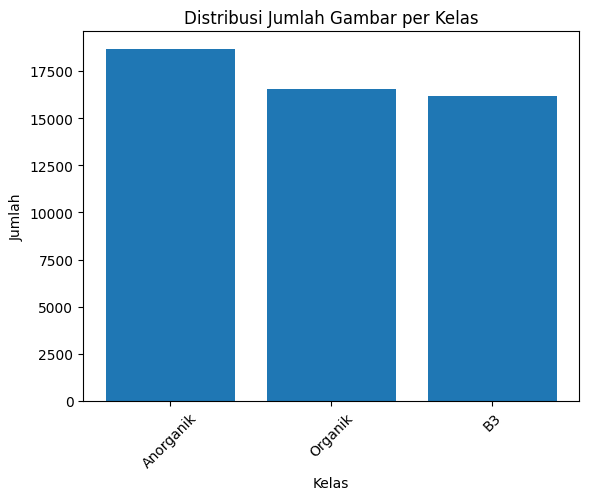

In [ ]:
classes = []
counts = []

for folder in os.listdir(base_path):
    path = os.path.join(base_path, folder)
    if os.path.isdir(path):
        classes.append(folder)
        counts.append(len(os.listdir(path)))

plt.figure()
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()

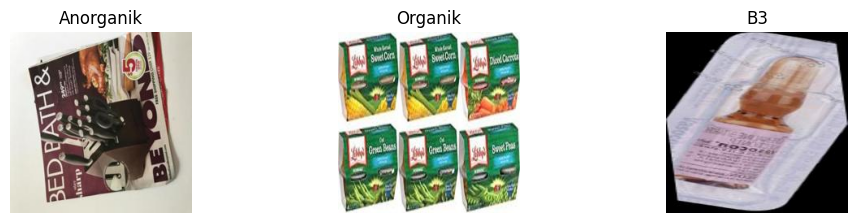

In [ ]:
plt.figure(figsize=(12,8))

i = 1
for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)

    if os.path.isdir(folder_path):
        img_file = random.choice(os.listdir(folder_path))
        img_path = os.path.join(folder_path, img_file)

        img = Image.open(img_path)

        plt.subplot(3,3,i)
        plt.imshow(img)
        plt.title(folder)
        plt.axis('off')
        i += 1

plt.show()

Berdasarkan hasil EDA, distribusi data antar kelas relatif seimbang sehingga tidak menimbulkan bias signifikan. Visualisasi sampel gambar menunjukkan bahwa label telah sesuai dan objek dapat dikenali dengan jelas. Selain itu, variasi ukuran gambar sudah sejenis semua dikarenakan sudah di resize pada bagian cleaning. Oleh karena itu, dataset dinilai layak untuk digunakan dalam pembangunan model dengan target akurasi minimal 85%.

#### Pertanyaan 2 : Jenis sampah apa yang memiliki jumlah data paling sedikit dan bagaimana distribusinya, sehingga dapat dilakukan penyeimbangan data sebelum proses training dalam waktu 1 minggu?

In [ ]:
data = []

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        data.append([folder, count])

df = pd.DataFrame(data, columns=["Class", "Count"])
df = df.sort_values(by="Count", ascending=True)

print(df)

       Class  Count
2         B3  16178
1    Organik  16559
0  Anorganik  18666


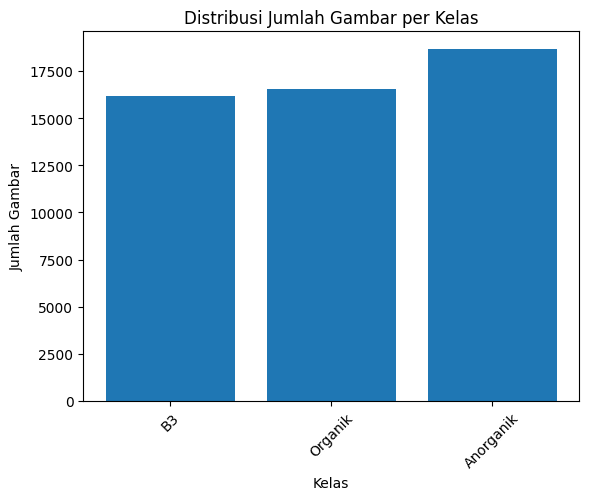

In [ ]:
plt.figure()
plt.bar(df["Class"], df["Count"])
plt.xticks(rotation=45)
plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.show()

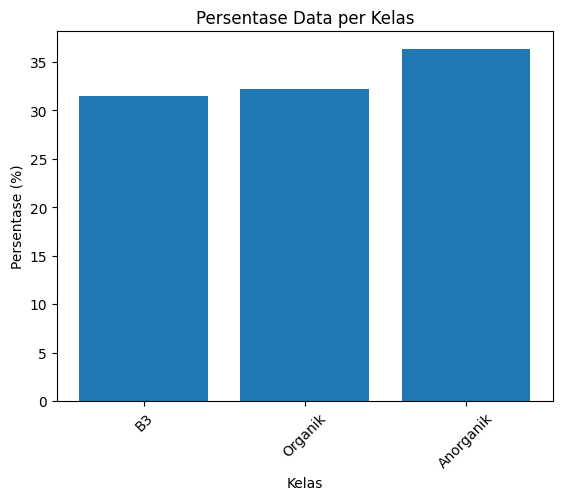

In [ ]:
df["Percentage"] = df["Count"] / df["Count"].sum() * 100

plt.figure()
plt.bar(df["Class"], df["Percentage"])
plt.xticks(rotation=45)
plt.title("Persentase Data per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Persentase (%)")
plt.show()

In [ ]:
max_count = df["Count"].max()
min_count = df["Count"].min()

imbalance_ratio = max_count / min_count
print("Imbalance ratio:", imbalance_ratio)

Imbalance ratio: 1.1537890963036221


Berdasarkan hasil eksplorasi data, diketahui bahwa kelas dengan jumlah data paling sedikit adalah anorganik, sedangkan kelas dengan jumlah terbanyak adalah organik. Visualisasi distribusi menunjukkan adanya ketidakseimbangan data dengan rasio sebesar 1.1537890963036221. Dikarenakan nilai imbalance ratio masih dalam rentang yang normal maka tidak perlu proses augmentasi ataupun penghapusan data

## SPLIT DATASET

In [ ]:
output_dir = "/content/drive/MyDrive/Dataset_Split"

# Rasio split
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

# Ambil semua folder class
classes = os.listdir(base_path)

for cls in classes:

    cls_path = os.path.join(base_path, cls)

    # Skip jika bukan folder
    if not os.path.isdir(cls_path):
        continue

    # Ambil semua gambar
    images = os.listdir(cls_path)

    # Filter hanya file gambar
    images = [
        img for img in images
        if img.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))
    ]

    # Split train+val dan test
    train_val, test = train_test_split(
        images,
        test_size=test_ratio,
        random_state=42,
        shuffle=True
    )

    # Split train dan val
    train, val = train_test_split(
        train_val,
        test_size=val_ratio / (train_ratio + val_ratio),
        random_state=42,
        shuffle=True
    )

    # Simpan ke folder train/val/test
    for subset, data in zip(
        ['train', 'val', 'test'],
        [train, val, test]
    ):

        subset_path = os.path.join(output_dir, subset, cls)

        os.makedirs(subset_path, exist_ok=True)

        for img in data:

            src = os.path.join(cls_path, img)
            dst = os.path.join(subset_path, img)

            shutil.copy(src, dst)

print("Dataset berhasil di-split!")

Dataset berhasil di-split!


In [ ]:
data_train = "/content/drive/MyDrive/Dataset_Split/train"

Cek total dataset train

In [ ]:
for folder in os.listdir(data_train):
    print(folder, len(os.listdir(os.path.join(data_train, folder))))

Anorganik 14932
Organik 13247
B3 12942
